<a href="https://colab.research.google.com/github/jakedog17/COP4630_HW1_Coding/blob/main/HW1-Coding/Homework_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Homework

This is the first assignment for CAP 4630 and we will develop two basic models with regression. \
You will use **"Tasks"** and **"Hints"** to finish the work. **(Total 70 Points)**


**Task Overview:**
- Singal Variable Nonlinear Regression
- Multiple Variable Linear Regression


## 1 - Packages ##

Import useful packages for scientific computing and data processing. **(2 Points)**

**Tasks:**
1. Import numpy and rename it to np.
2. Import pandas and rename it to pd.
3. Import the pyplot function in the libraray of matplotlib and rename it to plt.

References:
- [numpy](www.numpy.org) is the fundamental package for scientific computing with Python.
- [matplotlib](http://matplotlib.org) is a famous library to plot graphs in Python.

**Attention:**
1. After this renaming, you will use the new name to call functions. For example, **numpy** will become **np** in the following sections.


In [4]:
# Coding here
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## 2 - Data Preparation ##

Prepare the data for regression task. **(8 Points)**

**Tasks:**
1. Load data for nonlinear regression.
2. Generate the scatter plot of the data.

**Hints:**
1. The data file is "data_nonlinear.csv".
2. The data format is as follows: 1st column is X and 2nd column is Y.

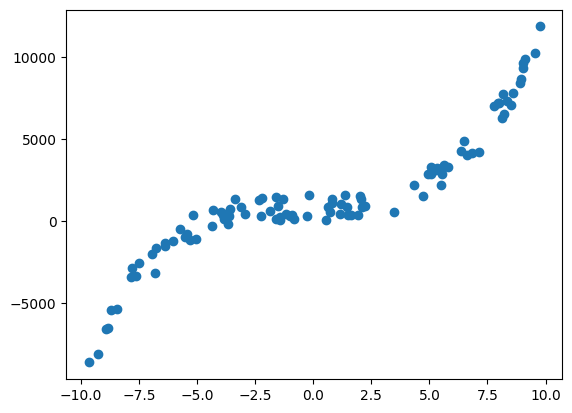

In [7]:
# Coding here

data_file_nonlinear = "/content/HW1_ProgramData/data_nonlinear.csv"

data = pd.read_csv(data_file_nonlinear)
X = data.iloc[:, 0]
Y = data.iloc[:, 1]
#Create Scatterplot
plt.scatter(X, Y)
plt.show()





## 3 - Single Variable Nonlinear Regression ##


Develop a regression model, estimate coefficients with data, and derive the relationship. **(20 Points)**

**Tasks:**
1. Establish a relationship between Y and X with a cubic function, such as Y= aX^3+ bX^2 + cX +d.
2. Compute MSE loss with observation-prediction pairs.
3. Implement **Gradient Descent (GD)** to achieve optimal solution with the learning rate of **0.000001 (1e-6)** and **10000 (1e4)** epochs.
4. Print out the optimal solution at final step.

**Hints:**  
1. Given the example of linear regression in class, modify the function to an equation for a spline with coefficients of **a** , **b**, **c** and **d** for cubic, qudractic, linear, and constant term.
2. Initialize the model with zero. For example, a=0, b=0, c=0 and d=0.
3. It may take **10-15 seconds**  to finish the running for 10000 steps. Be patient.
4. For debugging, the results of **a**, **b**, **c**, **d** for first five steps are as follows:

Epoch  0 :  2.8045093168662314 0.15006631239563697 0.04047903434004733 0.0030023401200892003 \
Epoch  1 :  4.905935374329749 0.2803623842843468 0.07068280026181122 0.0057565282228493 \
Epoch  2 :  6.480417434500056 0.395779237410925 0.09318576969022647 0.008323648642107889 \
Epoch  3 :  7.65996806232127 0.49998280146312246 0.10991745268097952 0.010749486523089888 \
Epoch  4 :  8.543527816733905 0.5957208253596222 0.12232397430880633 0.013068360586717544



In [23]:
# Coding here

#weights
a = 0
b = 0
c = 0
d = 0

L =  0.000001 # Learning Rate
epochs = 10000 # number of itersation to perform gradient descent

n = float(len(X)) # number of elements in X



#perform Gradient Descent
for i in range(epochs):
  Y_pred = a*(X**3) + b*(X**2) + c*X + d #prediction formula for non-linear relationship between Y and X

  # deritive for gradient descent with squared loss formula
  D_a = (-2/n) * sum((X**3)*(Y-Y_pred))
  D_b = (-2/n) * sum((X**2)*(Y-Y_pred))
  D_c = (-2/n) * sum((X)*(Y-Y_pred))
  D_d = (-2/n) * sum((Y-Y_pred))

  # the end product of gradient descent for each weight
  a = a - L * D_a
  b = b - L * D_b
  c = c - L * D_c
  d = d - L * D_d

  #debug strings
  if (i < 5):
    print("Epoch " + str(i) + " : " +str(a) + " " + str(b) + " " + str(c) + " " + str(d) )

#end result
print(a, b, c, d)



Epoch 0 : 2.804509316866232 0.15006631239563695 0.040479034340047314 0.0030023401200892003
Epoch 1 : 4.905935374329749 0.2803623842843468 0.0706828002618112 0.005756528222849298
Epoch 2 : 6.480417434500055 0.395779237410925 0.09318576969022646 0.008323648642107887
Epoch 3 : 7.659968062321269 0.49998280146312246 0.10991745268097951 0.010749486523089886
Epoch 4 : 8.543527816733905 0.5957208253596222 0.12232397430880632 0.013068360586717544
10.655168698725843 20.970276527941813 -1.8103041714197274 7.989333607627859


## 4 - Prediction Results ##

Derive prediction function and generate estmated results. **(2 Points)**

**Tasks:**
1. Derive prediction function with the obtained coefficients above.
2. Generate scatter plots for original data pairs X-Y and prediction results X-Y_Pred in the same figure.

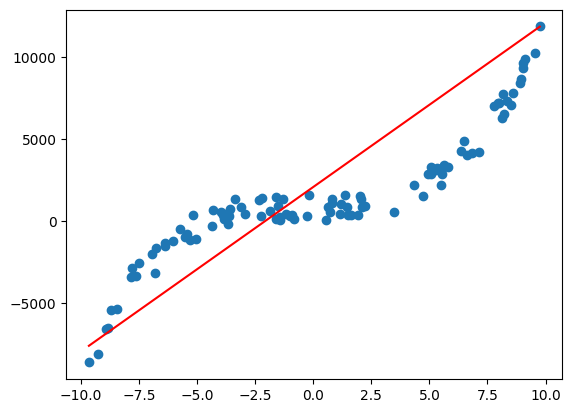

In [24]:
# Coding here

#prediction model with updated / trained weights
Y_pred = a*(X**3) + b*(X**2) + c*X + d

#do perdiction for model
plt.scatter(X, Y)
plt.plot([min(X), max(X)], [min(Y_pred), max(Y_pred)], color='red') # predicted
plt.show()



## 5 - Multiple Variables Linear Regression ##

## 5.1 Data Preparation

Prepare the data for regression task. **(8 Points)**

**Tasks:**
1. Load data for multiple variable linear regression.
2. Generate the 3D scatter plot of the data.

**Hints:**
1. The data file is "data_two_variables.csv".
2. The data format is as follows: 1st column is X1, 2nd column is X2, and 3rd colum is Y.
3. You may use "mplot3d" in the toolkit of "mpl_toolkits" and import "Axes3D" to faciliate 3D scatter plot. More details can be found in the reference of https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html
4. [Optional, NO Credit]You may rotate the figure you generated by using "%matplotlib qt" before you plot it. Remember to install the related package by "!pip install PyQt5". Only work on Jupyter(locally). Does not work on Google Colab. [Reference Website](https://stackoverflow.com/questions/14261903/how-can-i-open-the-interactive-matplotlib-window-in-ipython-notebook)

![](https://drive.google.com/uc?export=view&id=1sHwWfZXpU3-8SqzFrmCxIvxmQWfe2Nns)
![](https://drive.google.com/uc?export=view&id=1OwHP0g-K2um-LnKiDhE6UfkDFxk4Opce)


In [ ]:
# Coding here





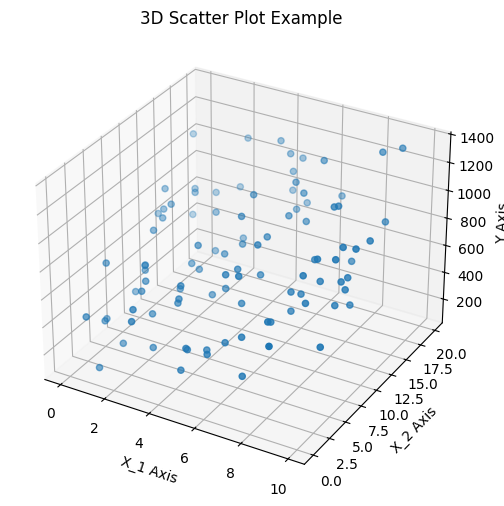

In [76]:
# Coding here

data_file_twoVar = "/content/HW1_ProgramData/data_two_variables.csv"


data_twoVar = pd.read_csv(data_file_twoVar)
X_1 = data_twoVar.iloc[:, 0]
X_2 = data_twoVar.iloc[:, 1]
Y = data_twoVar.iloc[:, 2]


#Create Scatterplot

# Initialize 3D figure and axes
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')

# Create the 3D scatter plot
scatter = ax.scatter(X_1, X_2, Y)

# Label axes
ax.set_xlabel('X_1 Axis')
ax.set_ylabel('X_2 Axis')
ax.set_zlabel('Y Axis')
ax.set_title('3D Scatter Plot Example')



plt.show()






## 5.2 Linear Regression

Develop a regression model, estimate coefficients with data, and derive the relationship. **(20 Points)**

**Tasks:**
1. Establish a linear function to describe the relationship among Y, X1, and X2.
2. Compute MSE loss with observation-prediction pairs.
3. Implement **Gradient Descent (GD)** to achieve optimal solution with the learning rate of **0.001 (1e-3)** and **10000 (1e4)** epochs.
4. Print out the optimal solution at final step.


**Hints:**  
1. Given the example of linear regression in class, modify the function to a linear equation with two independent variables X1 and X2. The coefficients of X1 and X2 are **m1** and **m2**, respectively. The constant term is **m3**.
2. Initialize the model with zero. For example, m1=0, m2=0, and m3=0.
3. It may take **10-15 seconds**  to finish the running for 10000 steps. Be patient.
4. For debugging, the results of **m1**, **m2**, and **m3** for first five steps are as follows:

Epoch 0: 7.43847600018326 15.595631430047339 1.4265844915879997 \
Epoch 1: 12.954483113402425 26.731746959534096 2.481143659135288 \
Epoch 2: 17.084193849045587 34.664109745712814 3.2680146970514863 \
Epoch 3: 20.213137348549306 40.2953527521597 3.8622050343066556 \
Epoch 4: 22.618552798604984 44.274269323103674 4.317638791453634 \
Epoch 5: 24.49983444185925, 47.06718627348913, 4.673084592175723

In [50]:
# Coding here

#weights
m_1 = 0
m_2 = 0
m_3 = 0

L = 0.001

epochs = 10000


for i in range(epochs):
  Y_pred = m_1*X_1 + m_2*X_2 + m_3


  # deritive for gradient descent with squared loss formula
  D_m_1 = (-2/n) * sum((X_1)*(Y-Y_pred))
  D_m_2 = (-2/n) * sum((X_2)*(Y-Y_pred))
  D_m_3 = (-2/n) * sum((Y-Y_pred))

  # the end product of gradient descent for each weight
  m_1 = m_1 - L * D_m_1
  m_2 = m_2 - L * D_m_2
  m_3 = m_3 - L * D_m_3

  #debug strings
  if (i < 6):
    print("Epoch " + str(i) + " : " +str(m_1) + " " + str(m_2) + " " + str(m_3) )

#end result
print(m_1, m_2, m_3)



Epoch 0 : 7.438476000183261 15.59563143004734 1.4265844915880002
Epoch 1 : 12.954483113402425 26.7317469595341 2.481143659135288
Epoch 2 : 17.084193849045587 34.66410974571282 3.268014697051486
Epoch 3 : 20.213137348549306 40.29535275215971 3.862205034306655
Epoch 4 : 22.618552798604984 44.27426932310368 4.317638791453633
Epoch 5 : 24.49983444185925 47.06718627348913 4.673084592175723
32.73494342264618 34.69592128962032 222.91661391579635



## 5.3 - Prediction Results ##

Derive prediction function and generate estmated results. **(10 Points)**

**Tasks:**
1. Derive prediction function with the obtained coefficients above.
2. Generate 3D scatter plots for original data pairs X-Y and prediction results X-Y_Pred in the same figure.

**Hint:**
1. You may follow the example above.
2. An example is shown below.
![](https://drive.google.com/uc?export=view&id=1xAl7eJmDmFPTNipd0SljAdyHs3PhRiMg)
![](https://drive.google.com/uc?export=view&id=1Eb9qZqTCmAbwJUkoTQ6zPys3ezWqTCkr)

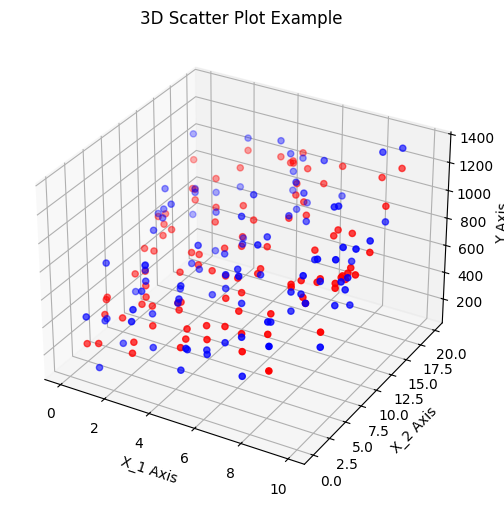

In [77]:
# Coding here

#prediction model
Y_pred = m_1*X_1 + m_2*X_2 + m_3


#Create Scatterplot

# Initialize 3D figure and axes
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')

# Create the 3D scatter plot

#OG data (blue)
ax.scatter(X_1, X_2, Y, color="blue")

#Predicted Data (red)
ax.scatter(X_1, X_2, Y_pred, color="red")

# Label axes
ax.set_xlabel('X_1 Axis')
ax.set_ylabel('X_2 Axis')
ax.set_zlabel('Y Axis')
ax.set_title('3D Scatter Plot Example')



plt.show()

